# RNA-seq関連
---

## DESeq2解析

PyDESeq2を使えば、PythonでDESeq2解析を行うことが可能です。<br>
DESeq2パッケージRにもありますので、Rでも解析可能です。<br>

PyDESeq2のインストール方法および使用方法は[こちら](https://pydeseq2.readthedocs.io/en/latest/auto_examples/plot_minimal_pydeseq2_pipeline.html)を読んでください。<br>
このページに記載されたDESeq2に関する情報は全て上記のサイトに記載されています。

まずはPyDESeq2から必要なパッケージをimportします。

In [1]:
import os

from pydeseq2.dds import DeseqDataSet
from pydeseq2.utils import load_example_data
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats


<br>ここではテストデータをダウンロードして使用します。<br>
以下の方法でリードカウントとメタデータのテストデータをダウンロードします。<br>
**実際の解析では、`RSEM`等の解析により得られたリードカウントのデータを使用することになります。**<br>

In [2]:
counts_df = load_example_data(
    modality="raw_counts",
    dataset="synthetic",
    debug=False,
)

metadata = load_example_data(
    modality="metadata",
    dataset="synthetic",
    debug=False,
)

print(counts_df)

           gene1  gene2  gene3  gene4  gene5  gene6  gene7  gene8  gene9  \
sample1       12     21      4    130     18      0     16     54     49   
sample2        1     44      2     63     11     10     70     32     57   
sample3        4      4     11    180     21      3     28     34     65   
sample4        1     10      2    100     44      9     28     16     33   
sample5        1     11      6    135     16      2     32     29     31   
...          ...    ...    ...    ...    ...    ...    ...    ...    ...   
sample96       7     26      3     67     11      4     41     44     54   
sample97       1     14      3     71     33      5     19     42     25   
sample98      10     36      2     72     11      2     66     27     16   
sample99      18     14      3     66     53     11     32     19     79   
sample100     21      9      3     42     13     13     19     78     30   

           gene10  
sample1         3  
sample2         9  
sample3         2  
sample4

In [3]:
print(metadata)

          condition group
sample1           A     X
sample2           A     Y
sample3           A     X
sample4           A     Y
sample5           A     X
...             ...   ...
sample96          B     Y
sample97          B     X
sample98          B     Y
sample99          B     X
sample100         B     Y

[100 rows x 2 columns]


<br>実データの場合は以下のようにアノテーション情報の有無やリードカウントでサンプルの絞り込みを行うことが推奨されます。<br>
このテストデータでは不要です。

In [4]:
samples_to_keep = ~metadata.condition.isna()
counts_df = counts_df.loc[samples_to_keep]
metadata = metadata.loc[samples_to_keep]

In [5]:
genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
counts_df = counts_df[genes_to_keep]

<br>`DeseqDataSet`オブジェクトを用いて、分散とlog-fold changeのパラメータを推定し、`dds`に格納します。<br>
`design`でメタデータの`condition`を入力することで、比較する群を指定します。

In [6]:
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata,
    design="~condition",
    refit_cooks=True,
    inference=inference,
    # n_cpus=8, # n_cpus can be specified here or in the inference object
)

<br>`deseq2`を使って解析を実行します。

In [7]:
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.02 seconds.

Fitting dispersion trend curve...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



<br>推定したパラメータにより、2群間の発現変化解析とWald検定を行います。

In [8]:
ds = DeseqStats(dds, contrast=["condition", "B", "A"], inference=inference)

<br>`summary()`で結果を表示します。

In [9]:
ds.summary()

Log2 fold change & Wald test p-value: condition B vs A
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene1     8.541317        0.632812  0.289101  2.188898  0.028604  0.064150
gene2    21.281239        0.538552  0.149963  3.591236  0.000329  0.001646
gene3     5.010123       -0.632830  0.295236 -2.143476  0.032075  0.064150
gene4   100.517961       -0.412102  0.118629 -3.473868  0.000513  0.001710
gene5    27.142450        0.582065  0.154706  3.762409  0.000168  0.001646
gene6     5.413043        0.001457  0.310311  0.004696  0.996253  0.996253
gene7    28.294023        0.134338  0.149945  0.895917  0.370297  0.411441
gene8    40.358344       -0.270656  0.136401 -1.984261  0.047227  0.078711
gene9    37.166183       -0.212715  0.133243 -1.596437  0.110391  0.143147
gene10   11.589325        0.386011  0.244588  1.578207  0.114518  0.143147


Running Wald tests...
... done in 0.02 seconds.



<br>結果は`ds.results_df`に格納されています。

In [10]:
print(ds.results_df)

          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene1     8.541317        0.632812  0.289101  2.188898  0.028604  0.064150
gene2    21.281239        0.538552  0.149963  3.591236  0.000329  0.001646
gene3     5.010123       -0.632830  0.295236 -2.143476  0.032075  0.064150
gene4   100.517961       -0.412102  0.118629 -3.473868  0.000513  0.001710
gene5    27.142450        0.582065  0.154706  3.762409  0.000168  0.001646
gene6     5.413043        0.001457  0.310311  0.004696  0.996253  0.996253
gene7    28.294023        0.134338  0.149945  0.895917  0.370297  0.411441
gene8    40.358344       -0.270656  0.136401 -1.984261  0.047227  0.078711
gene9    37.166183       -0.212715  0.133243 -1.596437  0.110391  0.143147
gene10   11.589325        0.386011  0.244588  1.578207  0.114518  0.143147


---
## Volcano plotの作成



DESeq2の結果を`df`に格納し、補正後p値を-log10値(score)に変換します。<br>


In [11]:
import numpy as np

df = ds.results_df
df['score'] = - np.log10(df['padj'])

print(df)

          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj  \
gene1     8.541317        0.632812  0.289101  2.188898  0.028604  0.064150   
gene2    21.281239        0.538552  0.149963  3.591236  0.000329  0.001646   
gene3     5.010123       -0.632830  0.295236 -2.143476  0.032075  0.064150   
gene4   100.517961       -0.412102  0.118629 -3.473868  0.000513  0.001710   
gene5    27.142450        0.582065  0.154706  3.762409  0.000168  0.001646   
gene6     5.413043        0.001457  0.310311  0.004696  0.996253  0.996253   
gene7    28.294023        0.134338  0.149945  0.895917  0.370297  0.411441   
gene8    40.358344       -0.270656  0.136401 -1.984261  0.047227  0.078711   
gene9    37.166183       -0.212715  0.133243 -1.596437  0.110391  0.143147   
gene10   11.589325        0.386011  0.244588  1.578207  0.114518  0.143147   

           score  
gene1   1.192805  
gene2   2.783685  
gene3   1.192805  
gene4   2.766992  
gene5   2.783685  
gene6   0.001630  
gene7   

<br>次に、発現量変化に応じてプロットする色を指定する列を追加します。<br>
ここではlog2値の絶対値0.2、score1.3(補正後p値0.05に相当)を基準にしていますが、示したい内容に応じて変更してください。<br>

In [12]:
import numpy as np

df = ds.results_df

df['color'] = 'Not significant'
df.loc[(df['log2FoldChange'] >= 0.2) & (df['score'] >= 1.3), 'color'] = 'Up'
df.loc[(df['log2FoldChange'] <= -0.2) & (df['score'] >= 1.3), 'color'] = 'Down'

print(df)

          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj  \
gene1     8.541317        0.632812  0.289101  2.188898  0.028604  0.064150   
gene2    21.281239        0.538552  0.149963  3.591236  0.000329  0.001646   
gene3     5.010123       -0.632830  0.295236 -2.143476  0.032075  0.064150   
gene4   100.517961       -0.412102  0.118629 -3.473868  0.000513  0.001710   
gene5    27.142450        0.582065  0.154706  3.762409  0.000168  0.001646   
gene6     5.413043        0.001457  0.310311  0.004696  0.996253  0.996253   
gene7    28.294023        0.134338  0.149945  0.895917  0.370297  0.411441   
gene8    40.358344       -0.270656  0.136401 -1.984261  0.047227  0.078711   
gene9    37.166183       -0.212715  0.133243 -1.596437  0.110391  0.143147   
gene10   11.589325        0.386011  0.244588  1.578207  0.114518  0.143147   

           score            color  
gene1   1.192805  Not significant  
gene2   2.783685               Up  
gene3   1.192805  Not significant

<br>X軸にFC(log2)、Y軸に補正後p値を指定します。<br>

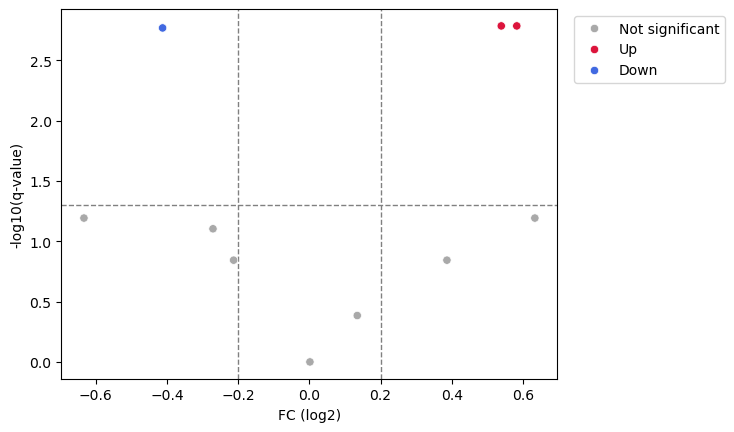

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
ax = sns.scatterplot(data = df, x = 'log2FoldChange', y = 'score', hue = 'color',
                     hue_order = ['Not significant', 'Up', 'Down'],
                     palette = ['darkgrey', 'crimson', 'royalblue'])
ax.axhline(1.3, zorder = 0, c = 'grey', lw = 1, ls = '--')
ax.axvline(0.2, zorder = 0, c = 'grey', lw = 1, ls = '--')
ax.axvline(-0.2, zorder = 0, c = 'grey', lw = 1, ls = '--')
plt.legend(loc = 1, bbox_to_anchor = (1.22, 1), frameon = False, prop = {'weight': 'bold'})
ax.set_xlabel('FC (log2)')
ax.set_ylabel('-log10(q-value)')
plt.legend(loc = 'upper left', bbox_to_anchor = (1.02, 1))

<br>有意差があるときに遺伝子名を表示させる場合は`plt`の`text`を使って以下のようにします。

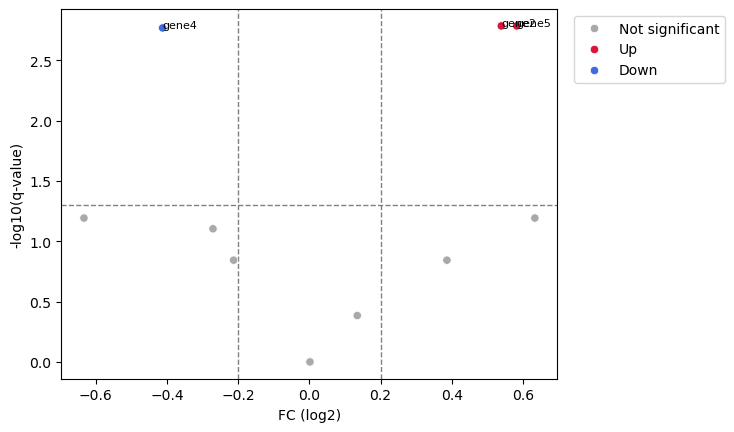

In [14]:
fig, ax = plt.subplots()
ax = sns.scatterplot(data = df, x = 'log2FoldChange', y = 'score', hue = 'color',
                     hue_order = ['Not significant', 'Up', 'Down'],
                     palette = ['darkgrey', 'crimson', 'royalblue'])
ax.axhline(1.3, zorder = 0, c = 'grey', lw = 1, ls = '--')
ax.axvline(0.2, zorder = 0, c = 'grey', lw = 1, ls = '--')
ax.axvline(-0.2, zorder = 0, c = 'grey', lw = 1, ls = '--')
plt.legend(loc = 1, bbox_to_anchor = (1.22, 1), frameon = False, prop = {'weight': 'bold'})
ax.set_xlabel('FC (log2)')
ax.set_ylabel('-log10(q-value)')
for i in range(len(df)):
    if abs(df.iloc[i].log2FoldChange) > 0.2 and df.iloc[i].score > 1.3:
        plt.text(x = df.iloc[i].log2FoldChange, y = df.iloc[i].score, s = df.iloc[i].name, fontsize = 8)
plt.legend(loc = 'upper left', bbox_to_anchor = (1.02, 1))